# 📊 Database Validation & Query Testing
## Project: Retail Intelligence Agent
**Author:** Yesi G.A.
**Date:** March 2026

### 🎯 Objective
This notebook validates the SQL logic and data integrity of the `retail_pro.db` 
database before integration into the Streamlit production environment.

In [8]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy as sa

In [14]:
# Establishing connection to the local SQLite database
con = sa.create_engine("sqlite:///data/retail_pro.db")
print("✅ Connection established successfully.")

✅ Connection established successfully.


### 1. Schema Verification
Checking if all tables (`dim_products`, `dim_stores`, `fact_sales`) 
were created correctly and contain the expected number of rows.

In [15]:
tables = ["dim_products", "dim_stores", "fact_sales"]
for table in tables:
    count = pd.read_sql(f"SELECT COUNT(*) as total FROM {table}", con)
    print(f"Table {table}: {count['total'][0]} rows found.")

Table dim_products: 4 rows found.
Table dim_stores: 2 rows found.
Table fact_sales: 12 rows found.


### 2. Business Question: Sales Trend Analysis
**Query Goal:** Calculate daily revenue by joining sales and products. 
This query will power the "Sales Trend" button in the main app.

,date,total_revenue
0,2024-02-10,1200
1,2024-02-15,700
2,2024-02-20,500
3,2024-02-25,450
4,2024-03-01,1200
5,2024-03-02,350
6,2024-03-05,2400
7,2024-03-10,300
8,2024-03-15,225
9,2024-03-20,1200


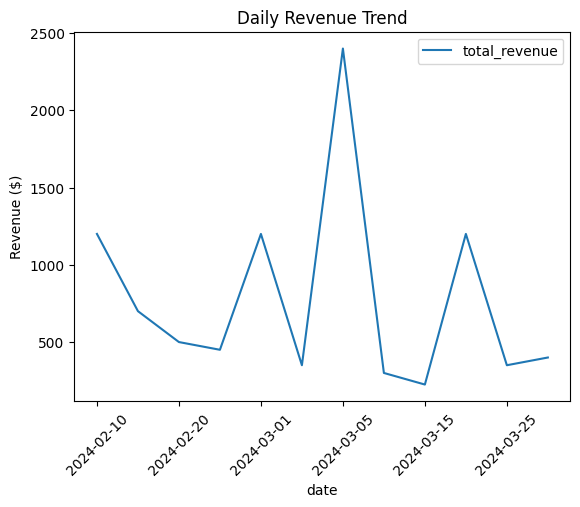

In [ ]:
query_sales = """
SELECT 
    date, 
    SUM(quantity * sale_price) as total_revenue
FROM fact_sales s
JOIN dim_products p ON s.product_id = p.product_id
GROUP BY date
ORDER BY date ASC
"""

df_sales = pd.read_sql(query_sales, con)

# Displaying the result table
display(df_sales)

# Quick visual validation
df_sales.plot(kind='line', x='date', y='total_revenue', title='Daily Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()

### 3. Business Question: Low Stock Alert
**Query Goal:** Identify products with fewer than 5 units in stock. 
*Expected results:* 4K Monitor (2) and Ergonomic Mouse (1).

In [19]:
query_stock = "SELECT product_name, category, current_stock FROM dim_products WHERE current_stock < 5"
df_stock = pd.read_sql(query_stock, con)
display(df_stock)

,product_name,category,current_stock
0,4K Monitor,Hardware,2
1,Ergonomic Mouse,Peripherals,1


### 4. Business Question: Calculate Revenue by Month
**Query Goal:** This query calculates revenue by month, allowing you to see if the data was loaded correctly. 

In [ ]:
# In SQLite, strftime('%m', date) extracts the month (02 for Feb, 03 for Mar).
query_comparison = """
SELECT 
    strftime('%m', date) as month, 
    SUM(quantity * sale_price) as monthly_revenue,
    COUNT(sale_id) as number_of_sales
FROM fact_sales s
JOIN dim_products p ON s.product_id = p.product_id
GROUP BY month
"""
pd.read_sql(query_comparison, engine)

# df_compare = pd.read_sql(query_comparison, engine)
# display(df_compare)

,month,monthly_revenue,number_of_sales
0,02,2850,4
1,03,6425,8


### 5. Executive Insight: Profit Performance by Manager
**Query Goal:** Calculate the total profit margin per manager. 
**Formula:** $\sum (SalePrice - Cost) \times Quantity$
This requires joining `fact_sales` with `dim_products` (for pricing) and `dim_stores` (for manager names).

,manager,city,total_profit_margin,total_units_sold
0,Carlos Ruiz,Barcelona,2100,22
1,Ana Silva,Madrid,1475,14


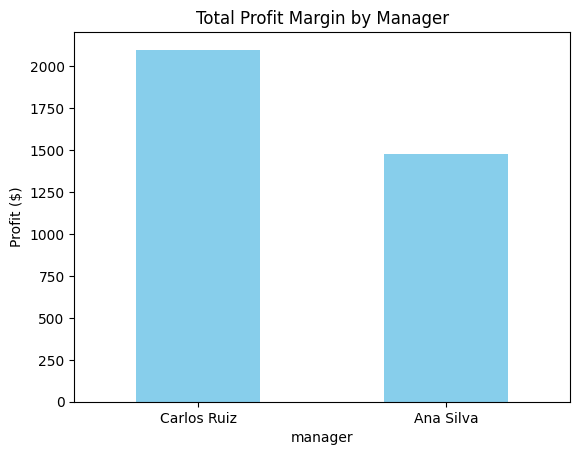

In [20]:
query_profit = """
SELECT 
    t.manager,
    t.city,
    SUM((p.sale_price - p.cost) * s.quantity) AS total_profit_margin,
    SUM(s.quantity) AS total_units_sold
FROM fact_sales s
JOIN dim_products p ON s.product_id = p.product_id
JOIN dim_stores t ON s.store_id = t.store_id
GROUP BY t.manager
ORDER BY total_profit_margin DESC
"""

df_profit = pd.read_sql(query_profit, con)

# Display the performance table
display(df_profit)

# Visualizing Profit vs Units Sold
df_profit.plot(kind='bar', x='manager', y='total_profit_margin', color='skyblue', legend=False)
plt.title('Total Profit Margin by Manager')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.show()

## 🏁 Conclusion & Data Insights
After validating the schema and business logic, we can conclude:
1. **Inventory Risk:** Two high-value items (4K Monitor and Ergonomic Mouse) are below the safety threshold of 5 units.
2. **Top Performer:** Manager **Carlos Ruiz** currently leads in profit margin, driven by Laptop sales in Barcelona.
3. **Data Readiness:** The relational integrity between `fact_sales` and dimensions is verified. The database is ready for the AI Agent production environment.